# Tarea 6: Red neuronal multicapa con optimización de hiperparámetros

## Universidad de Monterrey  
**Curso:** Artificial Intelligence II  
**Profesor:** Dr. Andrés Hernández Gutiérrez  

## Integrantes
- Jesús Leonardo Tamez 587400
- Ignacio Gaxiola 656752
- Cesar Del Rio — 634582


## Introducción

En esta tarea se construye una red neuronal multicapa para clasificación multiclase usando un dataset real de teléfonos móviles. El objetivo es predecir el rango de precio de un teléfono a partir de sus características técnicas, aplicando estandarización, optimización de hiperparámetros con Optuna y Early Stopping.

In [29]:
!pip install pandas numpy matplotlib seaborn scikit-learn tensorflow optuna

In [30]:
!pip install optuna
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    confusion_matrix, classification_report, accuracy_score,
    precision_score, recall_score, f1_score
)

import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

import optuna
from optuna.samplers import RandomSampler
from optuna.visualization import plot_param_importances, plot_parallel_coordinate

# 1. Descripción del dataset

El dataset corresponde a dispositivos móviles y fue obtenido de:

https://raw.githubusercontent.com/jose-morcillo/Predictive_Analytics/dasets/phone_classification.csv

Variable objetivo: "price_range" categoría de precio del teléfono (clasificación multiclase).

Variables predictivas: características técnicas como capacidad de batería, RAM, resolución de pantalla, entre otras. Es un dataset usable para este tipo de problema ya que tiene más de dos clases y múltiples variables de entrada.

In [31]:
# Importar los datos
url = 'https://raw.githubusercontent.com/jose-morcillo/Predictive_Analytics/dasets/phone_classification.csv'
df = pd.read_csv(url)
print(df.shape)
df.head()

(1850, 17)


,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,px_height,px_width,ram,talk_time,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,20,756,2549,19,0,1,Mid_Low
1,1021,1,0.5,1,0,1,53,0.7,136,3,905,1988,2631,7,1,0,Mid
2,563,1,0.5,1,2,1,41,0.9,145,5,1263,1716,2603,9,1,0,Mid
3,615,1,2.5,0,0,0,10,0.8,131,6,1216,1786,2769,11,0,0,Mid
4,1821,1,1.2,0,13,1,44,0.6,141,2,1208,1212,1411,15,1,0,Mid_Low


# 2. Limpieza de datos

Se revisa la calidad del dataset: valores nulos, filas duplicadas y clases válidas en la variable objetivo. Esto garantiza que el modelo aprenda de datos consistentes.

In [32]:
# Missing values
df.isnull().sum()

battery_power    0
blue             0
clock_speed      0
dual_sim         0
fc               0
four_g           0
int_memory       0
m_dep            0
mobile_wt        0
n_cores          0
px_height        0
px_width         0
ram              0
talk_time        0
touch_screen     0
wifi             0
price_range      0
dtype: int64

In [33]:
duplicates = df.duplicated().sum()
print("Duplicate rows:", duplicates)

Duplicate rows: 0


In [34]:
df['price_range'].unique()

<StringArray>
['Mid_Low', 'Mid', 'High', 'Low']
Length: 4, dtype: str

In [35]:
df.shape

(1850, 17)

## Interpretación

El dataset no presenta valores nulos ni duplicados, por lo que no fue necesario eliminar ni imputar registros. La variable price_range contiene las clases esperadas, así que se puede continuar directamente con el análisis exploratorio.

# 3. Análisis exploratorio de datos (EDA)

Se revisan estadísticas descriptivas, tipos de datos, distribución de clases, histogramas de variables clave y correlaciones entre variables.

In [36]:
df.describe()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,px_height,px_width,ram,talk_time,touch_screen,wifi
count,1850.000000,1850.000000,1850.000000,1850.00000,1850.000000,1850.000000,1850.000000,1850.000000,1850.000000,1850.000000,1850.000000,1850.000000,1850.000000,1850.000000,1850.000000,1850.000000
mean,1237.867027,0.493514,1.518216,0.50973,4.293514,0.521081,32.077838,0.503784,140.172432,4.497297,639.257297,1249.985405,2156.255135,10.965405,0.503784,0.506486
std,439.637778,0.500093,0.815346,0.50004,4.307767,0.499690,18.112633,0.289526,35.369486,2.296385,443.228426,434.449550,1106.593461,5.446519,0.500121,0.500093
min,501.000000,0.000000,0.500000,0.00000,0.000000,0.000000,2.000000,0.100000,80.000000,1.000000,0.000000,500.000000,256.000000,2.000000,0.000000,0.000000
25%,852.000000,0.000000,0.700000,0.00000,1.000000,0.000000,16.000000,0.200000,109.000000,2.000000,275.000000,870.500000,1187.000000,6.000000,0.000000,0.000000
50%,1224.500000,0.000000,1.500000,1.00000,3.000000,1.000000,32.000000,0.500000,141.000000,4.000000,553.000000,1248.000000,2217.500000,11.000000,1.000000,1.000000
75%,1619.000000,1.000000,2.200000,1.00000,7.000000,1.000000,48.000000,0.800000,170.000000,7.000000,941.000000,1633.750000,3135.750000,16.000000,1.000000,1.000000
max,1998.000000,1.000000,3.000000,1.00000,19.000000,1.000000,64.000000,1.000000,200.000000,8.000000,1960.000000,1998.000000,3998.000000,20.000000,1.000000,1.000000


In [37]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1850 entries, 0 to 1849
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  1850 non-null   int64  
 1   blue           1850 non-null   int64  
 2   clock_speed    1850 non-null   float64
 3   dual_sim       1850 non-null   int64  
 4   fc             1850 non-null   int64  
 5   four_g         1850 non-null   int64  
 6   int_memory     1850 non-null   int64  
 7   m_dep          1850 non-null   float64
 8   mobile_wt      1850 non-null   int64  
 9   n_cores        1850 non-null   int64  
 10  px_height      1850 non-null   int64  
 11  px_width       1850 non-null   int64  
 12  ram            1850 non-null   int64  
 13  talk_time      1850 non-null   int64  
 14  touch_screen   1850 non-null   int64  
 15  wifi           1850 non-null   int64  
 16  price_range    1850 non-null   str    
dtypes: float64(2), int64(14), str(1)
memory usage: 245.8 KB


In [38]:
df['price_range'].value_counts()

price_range
High       500
Low        487
Mid        463
Mid_Low    400
Name: count, dtype: int64

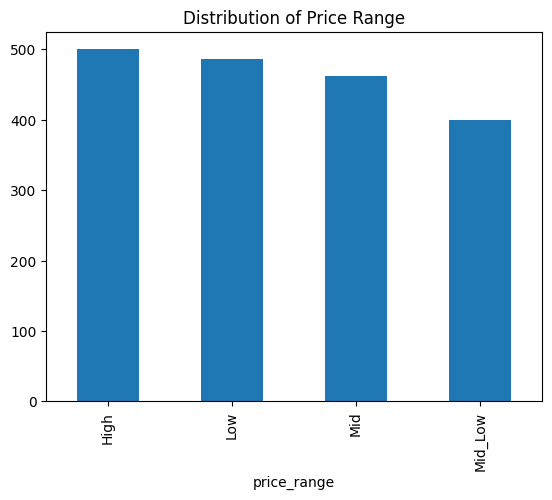

In [39]:
import matplotlib.pyplot as plt

df['price_range'].value_counts().plot(kind='bar')
plt.title("Distribution of Price Range")
plt.show()

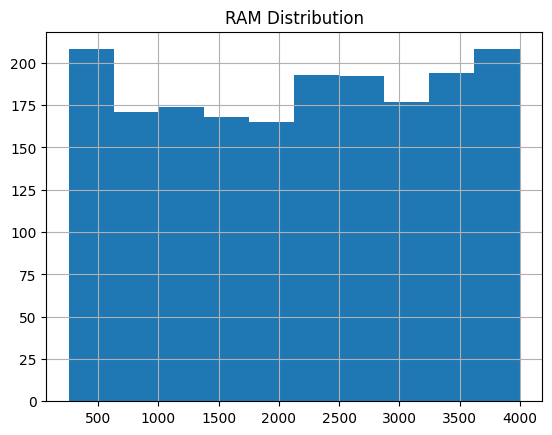

In [40]:
df['ram'].hist()
plt.title("RAM Distribution")
plt.show()

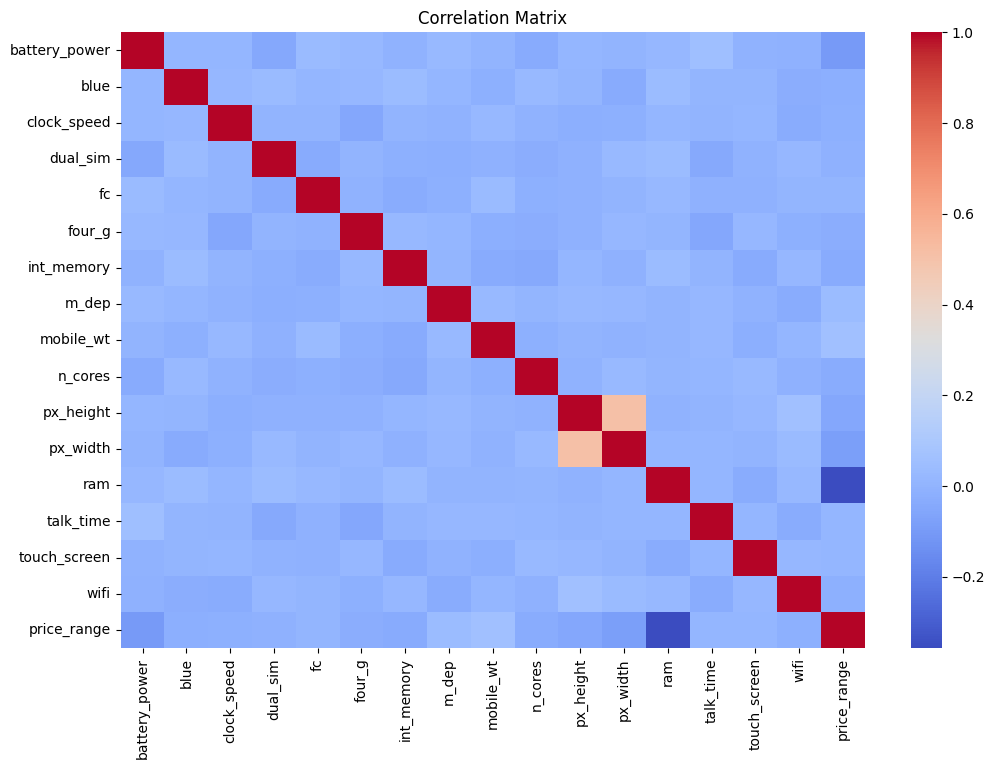

In [41]:
corr = df.copy()

le_temp = LabelEncoder()
corr['price_range'] = le_temp.fit_transform(corr['price_range'])

plt.figure(figsize=(12,8))
sns.heatmap(corr.corr(), cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

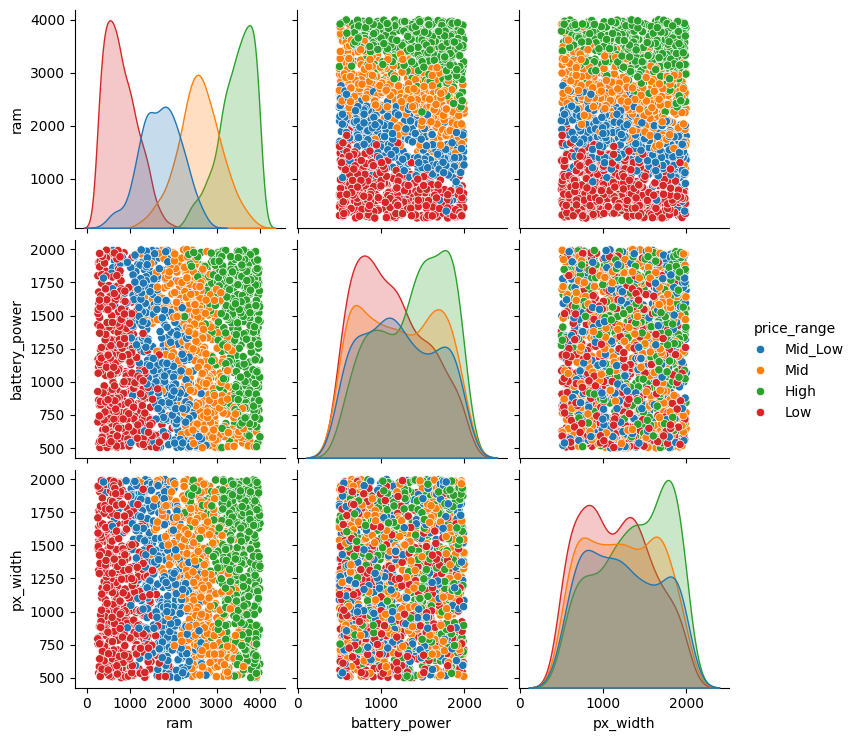

In [42]:
sns.pairplot(df[['ram', 'battery_power', 'px_width', 'price_range']], hue='price_range')
plt.show()

## Interpretación

Las variables tienen escalas bastante distintas, lo que justifica aplicar estandarización. Las clases de price_range están relativamente balanceadas, eso favorece un entrenamiento estable. La RAM es una de las variables con mayor correlación con la clase objetivo, algo que también se aprecia visualmente en el pairplot.

# 4. Preparación de datos para el modelado

Se separan las variables predictivas de la variable objetivo, se codifica price_range numéricamente y se divide el dataset en entrenamiento, validación y prueba. También se aplica estandarización.

In [43]:
X = df.drop('price_range', axis=1)
y = df['price_range']

In [44]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
print(label_encoder.classes_)

['High' 'Low' 'Mid' 'Mid_Low']


In [45]:
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42, stratify=y_train_full
)

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)

Train shape: (1184, 16)
Validation shape: (296, 16)
Test shape: (370, 16)


## División de datos

- Entrenamiento: ajustar pesos del modelo  
- Validación: monitorear desempeño durante el entrenamiento  
- Prueba: evaluación final del modelo  

Se usó división estratificada para mantener la proporción de clases en cada subconjunto.

In [46]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

## Estandarización
Se aplicó StandardScaler para que cada variable tenga media 0 y desviación estándar 1. Esto evita que variables con escalas grandes dominen el entrenamiento y mejora la convergencia del optimizador. El scaler se ajustó solo con los datos de entrenamiento.

# 5. Optimización de hiperparámetros

Se usó Random Search con Optuna para encontrar una buena configuración del modelo.

Hiperparámetros optimizados: learning rate, batch size, número de capas ocultas y neuronas por capa.

Se eligieron 20 trials como balance entre exploración del espacio de búsqueda y tiempo computacional disponible.

In [47]:
def objective(trial):
    # Hyperparameters to test
    learning_rate = trial.suggest_float("learning_rate", 1e-4, 1e-2, log=True)
    batch_size = trial.suggest_categorical("batch_size", [16, 32, 64, 128])
    n_layers = trial.suggest_int("n_layers", 2, 4)

    model = Sequential()
    model.add(tf.keras.Input(shape=(X_train.shape[1],)))

    for i in range(n_layers):
        units = trial.suggest_int(f"n_units_layer_{i}", 16, 512, step=16)
        model.add(Dense(units, activation="relu"))

    model.add(Dense(len(np.unique(y_encoded)), activation="softmax"))

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    early_stopping = EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True
    )

    model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=100,
        batch_size=batch_size,
        callbacks=[early_stopping],
        verbose=0
    )

    _, val_accuracy = model.evaluate(X_val, y_val, verbose=0)
    return val_accuracy

In [48]:
study = optuna.create_study(
    direction="maximize",
    sampler=RandomSampler(seed=42)
)

[I 2026-03-26 23:29:58,796] A new study created in memory with name: no-name-92590dab-dcdd-4206-8551-2f57a1463cf8


In [49]:
study.optimize(objective, n_trials=20)

[I 2026-03-26 23:30:03,851] Trial 0 finished with value: 0.9020270109176636 and parameters: {'learning_rate': 0.0005611516415334506, 'batch_size': 16, 'n_layers': 2, 'n_units_layer_0': 32, 'n_units_layer_1': 448}. Best is trial 0 with value: 0.9020270109176636.
[I 2026-03-26 23:30:06,969] Trial 1 finished with value: 0.8986486196517944 and parameters: {'learning_rate': 0.0015930522616241021, 'batch_size': 64, 'n_layers': 2, 'n_units_layer_0': 96, 'n_units_layer_1': 96}. Best is trial 0 with value: 0.9020270109176636.
[I 2026-03-26 23:30:13,725] Trial 2 finished with value: 0.9054054021835327 and parameters: {'learning_rate': 0.0004059611610484307, 'batch_size': 128, 'n_layers': 2, 'n_units_layer_0': 160, 'n_units_layer_1': 192}. Best is trial 2 with value: 0.9054054021835327.
[I 2026-03-26 23:30:17,629] Trial 3 finished with value: 0.9054054021835327 and parameters: {'learning_rate': 0.000816845589476017, 'batch_size': 16, 'n_layers': 2, 'n_units_layer_0': 320, 'n_units_layer_1': 96}. 

## Mejor configuración encontrada

A continuación se muestran los hiperparámetros del trial con mayor accuracy en validación. No garantiza ser el óptimo global, pero es el mejor de las 20 combinaciones exploradas.

In [50]:
print("Best validation accuracy:", study.best_value)
print("Best hyperparameters:")
for key, value in study.best_params.items():
    print(f"{key}: {value}")

Best validation accuracy: 0.9290540814399719
Best hyperparameters:
learning_rate: 0.000304867088345807
batch_size: 32
n_layers: 3
n_units_layer_0: 336
n_units_layer_1: 336
n_units_layer_2: 288


## Visualizaciones de Optuna

- Hyperparameter importances: muestra qué hiperparámetros tuvieron más impacto en el resultado.  
- Parallel coordinate plot: permite ver cómo distintas combinaciones se relacionan con el accuracy obtenido.

In [56]:
import sys
import subprocess
import importlib
from IPython.display import HTML, display

# Install plotting dependencies in the same Python environment as the kernel
subprocess.check_call([sys.executable, "-m", "pip", "install", "plotly", "nbformat"])

import plotly
import nbformat
print("Plotly version:", plotly.__version__)
print("nbformat version:", nbformat.__version__)

# Reload Optuna visualization modules to clear a deferred import failure state
import optuna.visualization._plotly_imports as optuna_plotly_imports
import optuna.visualization._param_importances as optuna_param_importances
importlib.reload(optuna_plotly_imports)
importlib.reload(optuna_param_importances)

fig = optuna.visualization.plot_param_importances(study)
display(HTML(fig.to_html(include_plotlyjs="cdn")))

Plotly version: 6.6.0
nbformat version: 5.10.4


C:\Users\Ignacio\AppData\Local\Temp\ipykernel_22228\1718514135.py:4: ExperimentalWarning: optuna.visualization.matplotlib._parallel_coordinate.plot_parallel_coordinate is experimental (supported from v2.2.0). The interface can change in the future.
  ax = plot_parallel_coordinate_mpl(study)
c:\Users\Ignacio\miniconda3\Lib\site-packages\optuna\visualization\matplotlib\_parallel_coordinate.py:115: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax2.set_ylim(dim.range[0], dim.range[1])


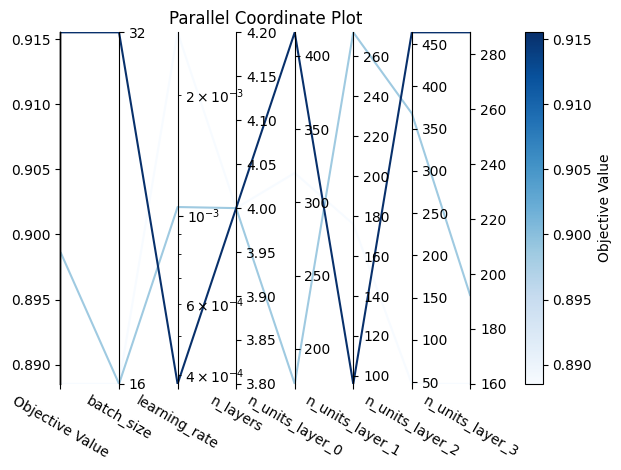

In [59]:
from optuna.visualization.matplotlib import plot_parallel_coordinate as plot_parallel_coordinate_mpl
import matplotlib.pyplot as plt

ax = plot_parallel_coordinate_mpl(study)
plt.tight_layout()
plt.show()

# 6. Construcción del modelo final

Se construye la red usando la configuración óptima encontrada por Optuna: número de capas y neuronas según el mejor trial, activación ReLU en capas ocultas, Softmax en la salida y Adam como optimizador.

In [60]:
best_params = study.best_params

final_model = Sequential()
final_model.add(tf.keras.Input(shape=(X_train.shape[1],)))

for i in range(best_params["n_layers"]):
    final_model.add(Dense(best_params[f"n_units_layer_{i}"], activation="relu"))

final_model.add(Dense(len(np.unique(y_encoded)), activation="softmax"))

final_model.compile(
    optimizer=Adam(learning_rate=best_params["learning_rate"]),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

final_model.summary()

Model: "sequential_40"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_146 (Dense)               │ (None, 336)            │         5,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_147 (Dense)               │ (None, 336)            │       113,232 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_148 (Dense)               │ (None, 288)            │        97,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_149 (Dense)               │ (None, 4)              │         1,156 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 217,156 (848.27 KB)

 Trainable params: 217,156 (848.27 KB)

 Non-trainable params: 0 (0.00 B)

# 7. Early Stopping

Se implementó EarlyStopping monitoreando val_loss con paciencia de 10 épocas. Esto detiene el entrenamiento cuando el modelo deja de mejorar en validación, evitando overfitting y conservando automáticamente los mejores pesos.

In [61]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history = final_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=best_params["batch_size"],
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5144 - loss: 1.1657 - val_accuracy: 0.6486 - val_loss: 0.8727
Epoch 2/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8057 - loss: 0.6413 - val_accuracy: 0.8615 - val_loss: 0.4692
Epoch 3/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9071 - loss: 0.3526 - val_accuracy: 0.9189 - val_loss: 0.2930
Epoch 4/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9468 - loss: 0.2236 - val_accuracy: 0.9020 - val_loss: 0.2482
Epoch 5/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9603 - loss: 0.1655 - val_accuracy: 0.9155 - val_loss: 0.2110
Epoch 6/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9679 - loss: 0.1253 - val_accuracy: 0.9020 - val_loss: 0.2178
Epoch 7/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9797 - loss: 0.0963 - val_accuracy: 0.9088 - val_loss: 0.2059
Epoch 8/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9823 - loss: 0.0838 - val_accuracy: 0.9020 - v

# 8. Curvas de aprendizaje

Se grafican accuracy y loss tanto de entrenamiento como de validación para detectar posibles casos de overfitting, underfitting o ajuste adecuado.

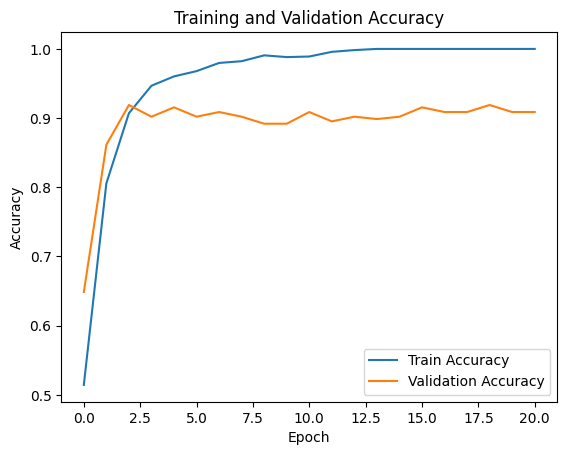

In [62]:
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

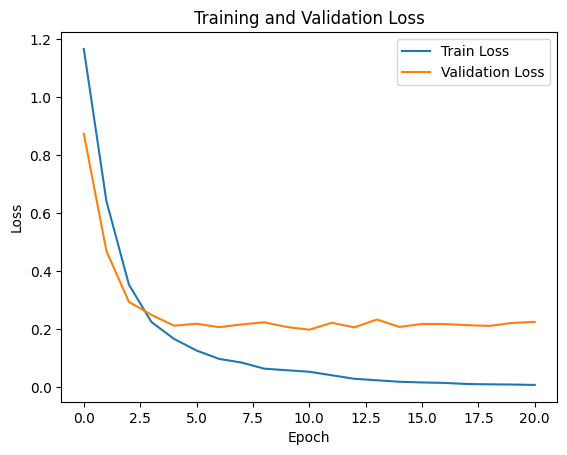

In [63]:
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

## Interpretación

Si ambas curvas evolucionan de forma similar y alcanzan valores altos, el modelo tiene un ajuste adecuado. Si la curva de entrenamiento supera mucho a la de validación, hay overfitting. Si ambas se quedan bajas, hay underfitting. Con base en las curvas obtenidas se determina cuál de estos casos aplica.

# 9. Evaluación con datos de prueba

Se evalúa el modelo final usando el conjunto de prueba, que no fue visto durante el entrenamiento ni la optimización, para medir la capacidad real de generalización.

In [ ]:
y_pred_probs = final_model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

#evaluation metrics

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average="weighted"))
print("Recall:", recall_score(y_test, y_pred, average="weighted"))
print("F1-score:", f1_score(y_test, y_pred, average="weighted"))

## Interpretación de métricas

- Accuracy: proporción de predicciones correctas sobre el total.  
- Precision: de lo que el modelo predijo como positivo, cuánto realmente lo era.  
- Recall: de los casos reales de cada clase, cuántos detectó correctamente.  
- F1-score: promedio armónico entre precision y recall.  
- Specificity: proporción de negativos identificados correctamente.  

En clasificación multiclase conviene analizar varias métricas, ya que un accuracy alto no siempre garantiza buen desempeño en todas las clases.

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

#tuvo solo 23 errores

## Interpretación de la matriz de confusión

Permite ver cuántos casos se clasificaron correctamente por clase y dónde se concentran los errores. Una diagonal dominante indica buen desempeño general.

In [ ]:
def multiclass_specificity(conf_matrix):
    specificities = []
    total = np.sum(conf_matrix)

    for i in range(conf_matrix.shape[0]):
        tp = conf_matrix[i, i]
        fn = np.sum(conf_matrix[i, :]) - tp
        fp = np.sum(conf_matrix[:, i]) - tp
        tn = total - (tp + fn + fp)
        specificity = tn / (tn + fp)
        specificities.append(specificity)

    return np.mean(specificities)

specificity = multiclass_specificity(cm)
print("Specificity:", specificity)

## Discusión del desempeño

Si accuracy, precision, recall, F1 y specificity presentan valores altos y consistentes, y la matriz de confusión muestra pocos errores, se puede concluir que el modelo generalizó bien al problema.

In [ ]:
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

# 10. Guardado y carga del modelo

Se guarda el modelo entrenado para poder reutilizarlo sin reentrenar desde cero. Después se carga para verificar que el archivo se generó correctamente.

In [ ]:
final_model.save("mobile_price_model.keras")
print("Model saved successfully.")

In [ ]:
loaded_model = load_model("mobile_price_model.keras")
print("Model loaded successfully.")

In [ ]:
loaded_model = load_model("mobile_price_model.keras")
print("Model loaded successfully.")

# 11. Conclusiones

César

En esta tarea aprendí el cómo se puede aplicar una red neuronal para poder resolver un problema de clasificación multiclase, practiqué el cómo optimizar los hiperparametros usando random search de optuna y eso ayudó a poder mejorar el desempeño del modelo y aprendí cómo usar el early stopping para evitar el overfitting y que el training fuera más eficiente

Aprendí cómo evaluar el modelo con datos como accuracy, precisión, recall, F-1 score y poder interpretar la matriz de confusión 

Esta tarea me ayudó a practicar el entrenar, optimizar y evaluar redes neuronales en un problema real

Leonardo

Esta actividad me permitió comprender de manera más profunda el impacto que tienen los hiperparámetros en el desempeño de una red neuronal. Uno de los principales aprendizajes fue que la selección adecuada de parámetros como la tasa de aprendizaje, el número de épocas y el tamaño del batch puede influir significativamente en la convergencia del modelo y en su capacidad de generalización. Asimismo, se observó que no siempre configuraciones más complejas o con mayores recursos garantizan mejores resultados.

La optimización de hiperparámetros resultó ser conveniente para agilizar procesos y monitoreo en el desempeño del modelo. Es por esto que, el implementar early stopping resultó ser particularmente efectivo, ya que permitió detener el entrenamiento en el punto óptimo, evitando el sobreajuste y reduciendo el tiempo de cómputo. Esto evidenció la importancia de implementar técnicas que mejoren la eficiencia sin sacrificar precisión

Ignacio

En esta actividad entendí mejor cómo aplicar una red neuronal a un problema real y cómo influyen los hiperparámetros en el resultado. Aprendí que no siempre un modelo más complejo es mejor, sino que encontrar una buena combinación de parámetros es lo importante.

El uso de Optuna me ayudó a automatizar ese proceso y el early stopping fue clave para evitar que el modelo se sobreentrenara y perder tiempo innecesario.

También reforcé cómo evaluar el modelo usando métricas como accuracy, precision y recall, además de interpretar la matriz de confusión.

En general, fue una buena práctica para ver todo el flujo de entrenamiento, optimización y evaluación de un modelo en un caso real.

## GitHub Repository
- Integrante 1: (https://github.com/Cesardlr/Multilayer_neural_network)
- Integrante 2: (https://github.com/LeoTG03/HW6_Multilayer_NeuronalNetwork_w_hyperparameter_optimisation.git)
- Integrante 3: (https://github.com/GaxCor/Multilayer_Neuronal_Network.git)

# 12. Referencias

- Dataset utilizado:  
  https://raw.githubusercontent.com/jose-morcillo/Predictive_Analytics/dasets/phone_classification.csv

- Documentación oficial de TensorFlow/Keras  
- Documentación oficial de Scikit-learn  
- Documentación oficial de Optuna